# Data Analysis - Projet final !! 🌷

## 1 - Import et explorations des données

### Description du Dataset — USGS Earthquake Catalog

#### Contexte

Ce dataset provient du **United States Geological Survey (USGS)**, l'agence scientifique 
fédérale américaine chargée de surveiller les ressources naturelles et les aléas naturels. 
Il recense les **événements sismiques** (séismes, explosions, effondrements) détectés par 
le réseau mondial de capteurs sismiques. L'étude de ces données permet de mieux comprendre 
la distribution géographique des séismes, leur intensité et leur évolution dans le temps, 
ce qui est essentiel pour la prévention des risques naturels.

#### Nature multidimensionnelle du dataset

Ce dataset est **multidimensionnel** au sens du cours, car il combine trois dimensions :

- **Dimension temporelle** — `time`, `updated` : date et heure exacte de l'événement (UTC)
- **Dimension spatiale** — `latitude`, `longitude`, `depth`, `place` : localisation précise 
  de l'épicentre et profondeur du foyer sismique (en km)
- **Dimension analytique** — caractéristiques mesurées de chaque séisme :
  - `mag` : magnitude du séisme (échelle de Richter)
  - `magType` : type de magnitude utilisé (ml, md, mb, mw...)
  - `depth` : profondeur du foyer en kilomètres
  - `nst` : nombre de stations ayant détecté le séisme
  - `gap` : angle azimutal maximal entre stations (qualité de localisation)
  - `dmin` : distance minimale entre l'épicentre et la station la plus proche
  - `rms` : résidu RMS de la localisation (qualité de la solution)
  - `net` : réseau sismique ayant détecté l'événement
  - `id` : identifiant unique de l'événement
  - `type` : type d'événement (earthquake, explosion, quarry blast...)
  - `status` : statut de validation (reviewed / automatic)
  - `horizontalError`, `depthError`, `magError`, `magNst` : indicateurs d'incertitude

#### Source et accès

**Source** : https://earthquake.usgs.gov/earthquakes/search/  
**Format** : CSV, 290 lignes, 22 colonnes  
**Unité d'observation** : un événement sismique détecté

### Import des bibliothèques 

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import duckdb 
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from prophet import Prophet
import plotly.graph_objs as go
from sklearn.cluster import KMeans
import plotly.express as px

#### Fonctions pour l'import et l'exploration du dataset

In [2]:
# Pour l'import du dataset
def load_data(path):
    """
    Charge le dataset CSV dans un DataFrame pandas.
    Input  : path : chemin du fichier CSV
    Output : df   : DataFrame pandas
    """
    df = pd.read_csv(path)
    # Conversion de la colonne temporelle en datetime
    df['time'] = pd.to_datetime(df['time'])
    df['updated'] = pd.to_datetime(df['updated'])
    return df

In [3]:
# Pour explorer la structure du dt set
def explore_structure(df):
    """
    Affiche la structure du dataset : dimensions, types de colonnes.
    Input  : df — DataFrame pandas
    Output : None (affichage console)
    """
    print("=" * 50)
    print(f" Nombre de lignes    : {df.shape[0]}")
    print(f" Nombre de colonnes  : {df.shape[1]}")
    print("=" * 50)
    print("\n Types de données par colonne :")
    print(df.dtypes)

In [4]:
# Pour explorer les valeures manquantes
def explore_missing(df):
    """
    Calcule et affiche le nombre de valeurs manquantes par colonne.
    Input  : df — DataFrame pandas
    Output : None (affichage console)
    """
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    
    result = pd.DataFrame({
        'Valeurs manquantes': missing,
        'Pourcentage (%)': missing_pct
    })
    
    print("=" * 50)
    print("Valeurs manquantes par colonne :")
    print("=" * 50)
    print(result[result['Valeurs manquantes'] > 0])

In [5]:
# Pour les statistiques descriptives
def explore_ranges(df):
    """
    Affiche les statistiques descriptives (min, max, moyenne, écart-type)
    pour toutes les colonnes numériques du dataset.
    Input  : df — DataFrame pandas
    Output : None (affichage console)
    """
    print("=" * 50)
    print("Statistiques descriptives des variables numériques :")
    print("=" * 50)
    print(df.describe().round(3))


In [6]:
# Pour visualiser rapidement la distribution des seismes
def plot_magnitude_distribution(df):
    """
    Affiche la distribution des magnitudes des séismes sous forme d'histogramme.
    Input  : df — DataFrame pandas
    Output : graphique Plotly
    """
    fig = px.histogram(
        df, 
        x='mag', 
        nbins=40,
        title="Distribution des magnitudes des séismes",
        labels={'mag': 'Magnitude', 'count': 'Nombre de séismes'},
        color_discrete_sequence=['steelblue']
    )
    fig.update_layout(bargap=0.1)
    fig.show()


## 2 - Requêtes d'extraction d'information

### Requête 1 — Agrégation par tranche de profondeur (groupby)

**Ce que représente la requête :**  
On regroupe les séismes selon leur profondeur (`depth`) en trois catégories standards 
utilisées en sismologie :
- **Superficiel** : profondeur < 70 km
- **Intermédiaire** : entre 70 et 300 km
- **Profond** : > 300 km

Pour chaque catégorie, on calcule **le nombre de séismes**, la **magnitude moyenne** et 
la **magnitude maximale**.

**Comment c'est calculé :**  
On utilise une requête SQL (via DuckDB, comme dans le TP2) avec un `CASE WHEN` pour créer 
les catégories de profondeur, puis un `GROUP BY` avec les fonctions d'agrégation 
`COUNT`, `AVG` et `MAX`.

In [9]:
# Pour la requête d'agrégation par tranche de profondeur
def query_groupby(df):
    """
    Agrège les séismes par catégorie de profondeur (superficiel/intermédiaire/profond).
    Calcule le nombre de séismes, la magnitude moyenne et maximale par catégorie.
    Input  : df — DataFrame pandas contenant les données sismiques
    Output : result — DataFrame pandas avec les résultats de l'agrégation
    """
    result = duckdb.sql("""
        SELECT 
            CASE 
                WHEN depth < 70 THEN 'Superficiel (< 70 km)'
                WHEN depth BETWEEN 70 AND 300 THEN 'Intermédiaire (70-300 km)'
                ELSE 'Profond (> 300 km)'
            END AS categorie_profondeur,
            COUNT(*) AS nb_seismes,
            ROUND(AVG(mag), 2) AS magnitude_moyenne,
            ROUND(MAX(mag), 2) AS magnitude_max
        FROM df
        GROUP BY categorie_profondeur
        ORDER BY nb_seismes DESC
    """).to_df()
    
    return result

In [10]:
# Pour visualiser la requête d'agrégation par profondeur
def plot_groupby(result):
    """
    Affiche un graphique en barres du nombre de séismes par catégorie de profondeur.
    Input  : result — DataFrame issu de query_groupby()
    Output : graphique Plotly
    """
    fig = px.bar(
        result,
        x='categorie_profondeur',
        y='nb_seismes',
        color='magnitude_moyenne',
        title="Nombre de séismes et magnitude moyenne par tranche de profondeur",
        labels={
            'categorie_profondeur': 'Catégorie de profondeur',
            'nb_seismes': 'Nombre de séismes',
            'magnitude_moyenne': 'Magnitude moyenne'
        },
        color_continuous_scale='Reds',
        text='nb_seismes'
    )
    fig.update_traces(textposition='outside')
    fig.show()

### Requête 2 — Fouille de motifs fréquents (Apriori)

**Ce que représente la requête :**  
On cherche les **combinaisons de caractéristiques qui apparaissent souvent ensemble** dans 
les séismes. Pour cela, on transforme chaque séisme en une "transaction" composée de :
- sa catégorie de magnitude (faible / modérée / forte)
- sa catégorie de profondeur (superficiel / intermédiaire / profond)
- son type d'événement (`type`)
- son statut de validation (`status`)

**Comment c'est calculé :**  
On applique l'algorithme **Apriori** (via la librairie `mlxtend`, comme dans le TP7) pour 
extraire les itemsets fréquents selon un support minimal, puis on génère des **règles 
d'association** mesurées par le *lift* (force de l'association).

**Interprétation attendue :**  
Cette requête permet de découvrir des profils-types de séismes (par exemple : "un séisme 
superficiel de faible magnitude est souvent de type earthquake et validé manuellement").

In [13]:
# Pour la fouille de motifs fréquents (Apriori) sur les caractéristiques des séismes
def query_frequent_patterns(df, min_support=0.1):
    """
    Cherche les combinaisons de caractéristiques fréquentes dans les séismes via Apriori.
    Discrétise magnitude et profondeur, puis extrait les règles d'association.
    Input  : df          — DataFrame pandas contenant les données sismiques
             min_support — support minimal pour Apriori (défaut 0.1)
    Output : rules — DataFrame pandas des règles d'association triées par lift
    """
    # Copie de travail
    data = df.copy()

    # Discrétisation de la magnitude en 3 catégories (voir pd.cut du TP7)
    data['mag_cat'] = pd.cut(
        data['mag'],
        bins=[0, 3.5, 5, 10],
        labels=['mag_faible', 'mag_moderee', 'mag_forte']
    )

    # Discrétisation de la profondeur en 3 catégories
    data['depth_cat'] = pd.cut(
        data['depth'],
        bins=[-1, 70, 300, 1000],
        labels=['superficiel', 'intermediaire', 'profond']
    )

    # Sélection des colonnes catégorielles utiles
    df_selected = data[['mag_cat', 'depth_cat', 'type', 'status']].copy()
    df_selected = df_selected.astype(str)

    # Transformation en liste de transactions (une par séisme)
    transactions = df_selected.apply(lambda row: list(row.values), axis=1).tolist()

    # Encodage one-hot avec TransactionEncoder
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

    # Extraction des itemsets fréquents avec Apriori
    patterns = apriori(df_encoded, min_support=min_support, use_colnames=True)

    # Génération des règles d'association (mesure : lift, comme TP7)
    rules = association_rules(
        patterns, metric="lift", min_threshold=1, num_itemsets=len(df_encoded)
    )

    # Tri par lift décroissant
    rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

    return rules

In [49]:
# Pour visualiser les meilleures règles d'association sous forme de diagramme de Sankey
def plot_frequent_patterns_sankey(rules, top_n=6):
    """
    Affiche les meilleures règles d'association (par lift) sous forme de diagramme de Sankey.
    Input  : rules — DataFrame issu de query_frequent_patterns()
             top_n — nombre de règles à afficher (défaut 6 pour rester lisible)
    Output : diagramme Sankey Plotly
    """
    import plotly.graph_objects as go

    # Sélection des top règles par lift (les plus fortes associations)
    top = rules.sort_values('lift', ascending=False).head(top_n)

    # Liste de tous les noeuds uniques (antécédents + conséquents), comme TP7
    allnodes = list(set(
        [str(sorted(list(x))) for x in top['antecedents']] +
        [str(sorted(list(x))) for x in top['consequents']]
    ))

    # Indices source (antécédents) et target (conséquents)
    source_indices = [allnodes.index(str(sorted(list(x)))) for x in top['antecedents']]
    target_indices = [allnodes.index(str(sorted(list(x)))) for x in top['consequents']]

    # Valeurs = la confidence de chaque règle (épaisseur des flux)
    conf_values = list(top['confidence'])

    # Construction du diagramme de Sankey (comme TP7)
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=allnodes,
            color="steelblue",
            pad=15,
            thickness=20
        ),
        link=dict(
            source=source_indices,
            target=target_indices,
            value=conf_values
        )
    )])
    fig.update_layout(
        title_text=f"Top {top_n} règles d'association – Diagramme de Sankey",
        font_size=12
    )
    print("Règles affichées dans le Sankey :")
    print(top[['antecedents', 'consequents', 'confidence']])
    fig.show()

### Requête 3 — Analyse temporelle : prévision du nombre de séismes (Prophet)

**Ce que représente la requête :**  
On agrège le nombre de séismes par période (par mois) afin d'obtenir une série temporelle, 
puis on utilise l'algorithme **Prophet** (vu en TP5) pour **prévoir** l'évolution du nombre 
de séismes sur les périodes futures.

**Comment c'est calculé :**  
1. On extrait la date de chaque séisme (`time`) et on compte le nombre d'événements par mois.
2. On renomme les colonnes en `ds` (date) et `y` (valeur) comme l'exige Prophet.
3. On entraîne le modèle Prophet avec un intervalle de confiance de 95%.
4. On génère des prédictions futures et on visualise la série réelle vs la prédiction.


In [37]:
# Pour l'analyse temporelle : prévision du nombre de séismes avec Prophet
def query_temporal(df, periods=24, freq='h'):
    """
    Agrège le nombre de séismes par heure et prévoit les périodes futures avec Prophet.
    Input  : df      — DataFrame pandas contenant les données sismiques
             periods — nombre de périodes futures à prédire (défaut 24 = 1 jour)
             freq    — fréquence d'agrégation ('h' = par heure)
    Output : model      — modèle Prophet entraîné
             prediction — DataFrame des prédictions (ds, yhat, yhat_lower, yhat_upper)
             serie      — série temporelle réelle (ds, y)
    """
    # Copie de travail et extraction de la date (sans le fuseau horaire)
    data = df.copy()
    data['time'] = pd.to_datetime(data['time']).dt.tz_localize(None)

    # Comptage du nombre de séismes par heure
    serie = (
        data.set_index('time')
            .resample(freq)
            .size()
            .reset_index(name='y')
    )

    # Renommage des colonnes pour Prophet (ds = date, y = valeur), comme TP5
    serie.columns = ['ds', 'y']

    # Entraînement du modèle Prophet avec intervalle de confiance de 95%
    model = Prophet(interval_width=0.95)
    model.fit(serie)

    # Création des dates futures et prédiction
    future_dates = model.make_future_dataframe(periods=periods, freq=freq)
    prediction = model.predict(future_dates)

    return model, prediction, serie

In [38]:
# Pour visualiser la série réelle et la prédiction Prophet
def plot_temporal(prediction, serie):
    """
    Affiche la série temporelle réelle et la prédiction Prophet sur le même graphique.
    Input  : prediction — DataFrame des prédictions issu de query_temporal()
             serie      — série temporelle réelle (ds, y)
    Output : graphique Plotly
    """
    fig = go.Figure()

    # Série réelle (comme TP5)
    fig.add_trace(go.Scatter(
        x=serie['ds'], y=serie['y'],
        name='Nombre réel de séismes',
        mode='lines+markers',
        line=dict(color='blue')
    ))

    # Série prédite
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat'],
        name='Prédiction',
        mode='lines',
        line=dict(color='red', dash='dash')
    ))

    # Intervalle de confiance
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat_upper'],
        mode='lines', line=dict(width=0), showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat_lower'],
        mode='lines', line=dict(width=0),
        fill='tonexty', fillcolor='rgba(255,0,0,0.1)',
        name='Intervalle de confiance 95%'
    ))

    fig.update_layout(
        title="Prévision du nombre de séismes par mois (Prophet)",
        xaxis_title='Date',
        yaxis_title='Nombre de séismes'
    )
    fig.show()

In [36]:
# Diagnostic : étendue temporelle du dataset
data_check = load_data("/Users/sarahchammari/Desktop/Projet data analysis/query (1).csv")
print("Date min :", data_check['time'].min())
print("Date max :", data_check['time'].max())
print("Durée totale :", data_check['time'].max() - data_check['time'].min())
print("Nombre de jours distincts :", data_check['time'].dt.date.nunique())

Date min : 2026-04-18 00:28:21.763000+00:00
Date max : 2026-04-23 08:24:03.931000+00:00
Durée totale : 5 days 07:55:42.168000
Nombre de jours distincts : 6


### Requête 4 — Analyse spatiale : clustering géographique des séismes (K-Means)

**Ce que représente la requête :**  
On regroupe les séismes en **zones géographiques** à l'aide de l'algorithme **K-Means** 
(vu en TP6), appliqué aux coordonnées `latitude` et `longitude`. Chaque cluster correspond 
à une région du globe où les séismes se concentrent.

**Comment c'est calculé :**  
1. On applique K-Means sur les colonnes `latitude` et `longitude` pour partitionner les 
   séismes en K clusters.
2. Chaque séisme reçoit un numéro de cluster.
3. On visualise les clusters sur une carte interactive (`scatter_mapbox`, comme TP6).

**Interprétation attendue :**  
Cette requête permet d'identifier les **grandes zones sismiques** du dataset et de voir 
comment les séismes se répartissent géographiquement à travers le monde.

In [43]:
# Pour l'analyse spatiale : clustering géographique des séismes avec K-Means
def query_spatial(df, n_clusters=5):
    """
    Regroupe les séismes en zones géographiques avec K-Means sur latitude/longitude.
    Input  : df         — DataFrame pandas contenant les données sismiques
             n_clusters — nombre de clusters géographiques (défaut 5)
    Output : data — DataFrame avec une colonne 'cluster' indiquant la zone de chaque séisme
    """
    # Copie de travail
    data = df.copy()

    # Application de K-Means sur latitude et longitude (comme TP6)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    data['cluster'] = kmeans.fit_predict(data[['latitude', 'longitude']])

    # Conversion en chaîne pour la coloration de la carte
    data['cluster'] = data['cluster'].astype(str)

    return data

In [44]:
# Pour l'analyse spatiale : clustering géographique des séismes avec K-Means
def query_spatial(df, n_clusters=5):
    """
    Regroupe les séismes en zones géographiques avec K-Means sur latitude/longitude.
    Input  : df         — DataFrame pandas contenant les données sismiques
             n_clusters — nombre de clusters géographiques (défaut 5)
    Output : data — DataFrame avec une colonne 'cluster' indiquant la zone de chaque séisme
    """
    # Copie de travail
    data = df.copy()

    # Application de K-Means sur latitude et longitude (comme TP6)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    data['cluster'] = kmeans.fit_predict(data[['latitude', 'longitude']])

    # Conversion en chaîne pour la coloration de la carte
    data['cluster'] = data['cluster'].astype(str)

    return data

In [45]:
# Pour visualiser les clusters de séismes sur une carte
def plot_spatial(data):
    """
    Affiche les séismes colorés par cluster géographique sur une carte interactive.
    Input  : data — DataFrame issu de query_spatial() (contient la colonne 'cluster')
    Output : carte Plotly
    """
    fig = px.scatter_mapbox(
        data,
        lat='latitude',
        lon='longitude',
        color='cluster',
        size='mag',                 # taille du point = magnitude du séisme
        size_max=15,
        zoom=1,
        hover_data=['mag', 'depth', 'place'],
        title="Répartition géographique des séismes par cluster"
    )
    fig.update_layout(mapbox_style="carto-positron")
    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    fig.show()

### Appel des fonctions

PARTIE 1 — Exploration des données
 Nombre de lignes    : 290
 Nombre de colonnes  : 22

 Types de données par colonne :
time               datetime64[ns, UTC]
latitude                       float64
longitude                      float64
depth                          float64
mag                            float64
magType                         object
nst                              int64
gap                              int64
dmin                           float64
rms                            float64
net                             object
id                              object
updated            datetime64[ns, UTC]
place                           object
type                            object
horizontalError                float64
depthError                     float64
magError                       float64
magNst                         float64
status                          object
locationSource                  object
magSource                       object
dtype: object
Valeurs

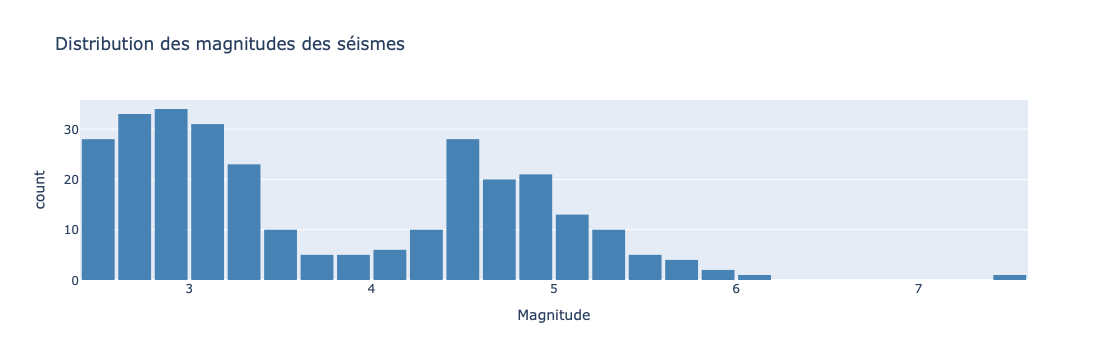


REQUÊTE 1 — Agrégation par tranche de profondeur
        categorie_profondeur  nb_seismes  magnitude_moyenne  magnitude_max
0      Superficiel (< 70 km)         242               3.65            7.4
1  Intermédiaire (70-300 km)          40               4.04            5.5
2         Profond (> 300 km)           8               4.36            4.5


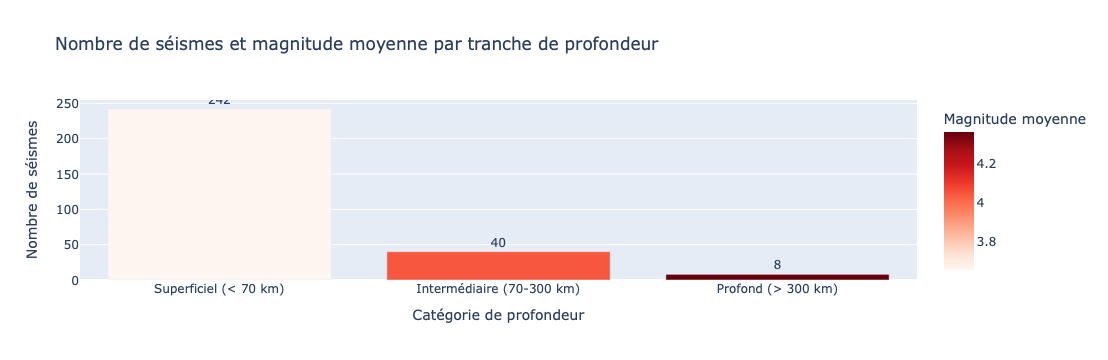


REQUÊTE 2 — Fouille de motifs fréquents (Apriori)
                          antecedents                         consequents  \
0                       (superficiel)            (mag_faible, earthquake)   
1           (earthquake, superficiel)                        (mag_faible)   
2                       (superficiel)                        (mag_faible)   
3                        (mag_faible)           (earthquake, superficiel)   
4            (mag_faible, earthquake)                       (superficiel)   
5                        (mag_faible)                       (superficiel)   
6           (earthquake, superficiel)              (mag_faible, reviewed)   
7                       (superficiel)              (mag_faible, reviewed)   
8  (mag_faible, earthquake, reviewed)                       (superficiel)   
9                       (superficiel)  (mag_faible, earthquake, reviewed)   

    support  confidence      lift  
0  0.496552    0.595041  1.099121  
1  0.496552    0.595041  1.09

/opt/anaconda3/lib/python3.13/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning:

invalid value encountered in divide



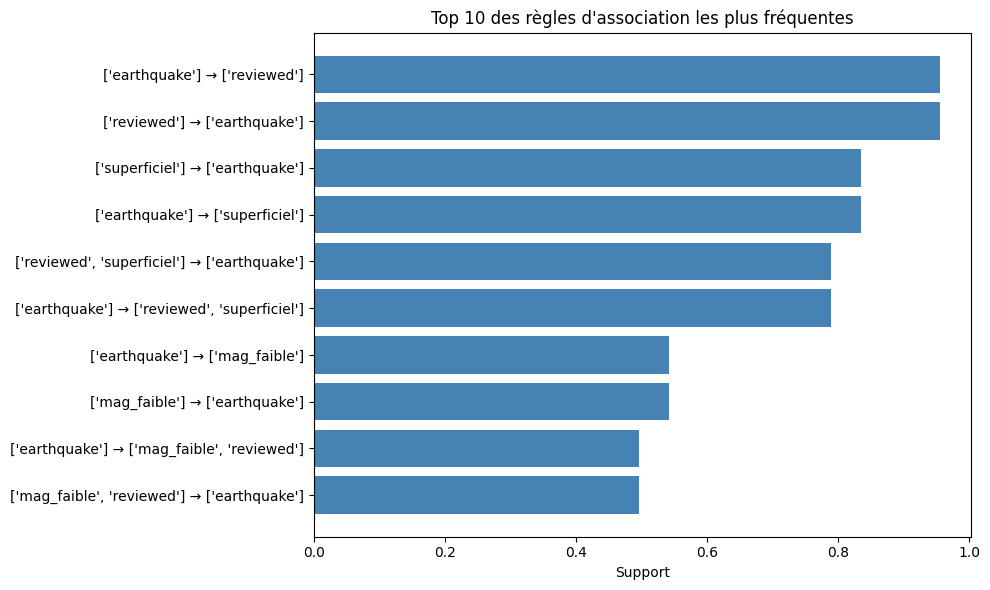

Règles affichées dans le Sankey :
                 antecedents                consequents  confidence
0              (superficiel)   (mag_faible, earthquake)    0.595041
2              (superficiel)               (mag_faible)    0.595041
1  (earthquake, superficiel)               (mag_faible)    0.595041
3               (mag_faible)  (earthquake, superficiel)    0.917197
4   (mag_faible, earthquake)              (superficiel)    0.917197
5               (mag_faible)              (superficiel)    0.917197


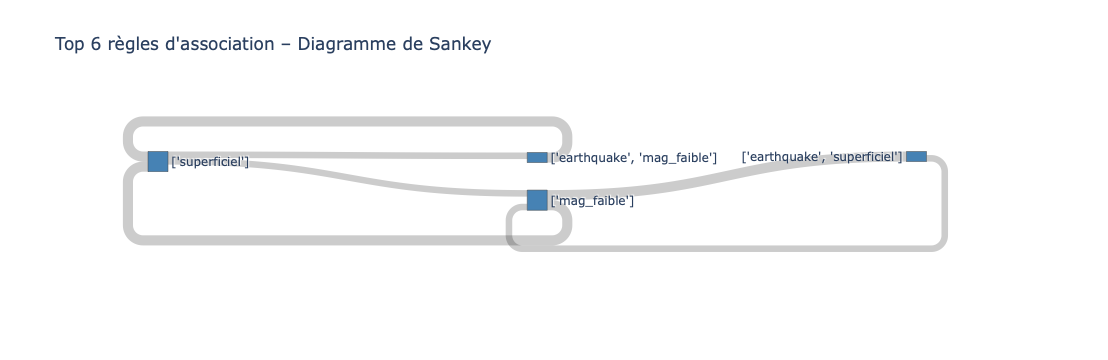

13:17:46 - cmdstanpy - INFO - Chain [1] start processing
13:17:46 - cmdstanpy - INFO - Chain [1] done processing



REQUÊTE 3 — Analyse temporelle (Prophet)
                     ds      yhat  yhat_lower  yhat_upper
129 2026-04-23 09:00:00  1.551574   -1.005992    3.977756
130 2026-04-23 10:00:00  2.049597   -0.613700    4.642218
131 2026-04-23 11:00:00  2.324104   -0.556503    5.029859
132 2026-04-23 12:00:00  2.138812   -0.541197    4.763897
133 2026-04-23 13:00:00  1.662256   -0.983961    4.353011
134 2026-04-23 14:00:00  1.334400   -1.496847    4.041244


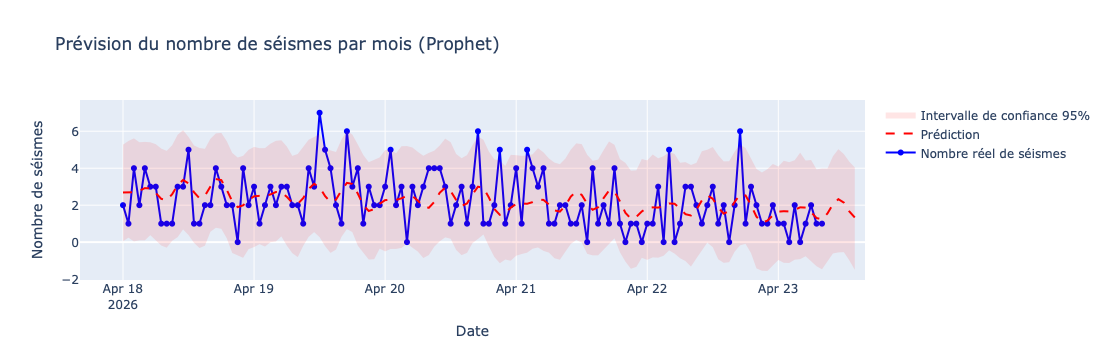


REQUÊTE 4 — Analyse spatiale (K-Means)
cluster
0    79
2    77
1    66
4    49
3    19
Name: count, dtype: int64


/var/folders/st/z6h95qm524sg85h5bppz7v1m0000gn/T/ipykernel_2538/501713603.py:8: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/opt/anaconda3/lib/python3.13/site-packages/plotly/express/_core.py:2530: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/opt/anaconda3/lib/python3.13/site-packages/_plotly_utils/basevalidators.py:2626: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/opt/anaconda3/lib/python3.13/site-packages/plotly/express/_core.py:2557: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/opt/anaconda3/lib/python3.13/site-packages/plotly/express/_core.py:2557: DeprecationWarning:

*scattermapbox* is deprecated! Us

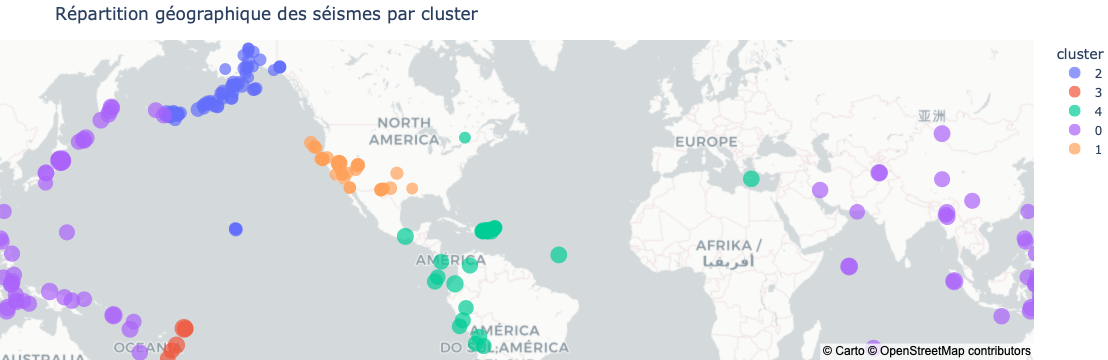

In [52]:

def main():
    """
    Fonction principale qui orchestre l'ensemble du projet.
    Elle appelle toutes les fonctions dans l'ordre logique du KDD process.
    Input  : None
    Output : None
    """
    
    # -------------------------------------------------------
    # PARTIE 1 — Chargement et exploration des données
    # -------------------------------------------------------
    print("=" * 50)
    print("PARTIE 1 — Exploration des données")
    print("=" * 50)
    
    df = load_data("/Users/sarahchammari/Desktop/Projet data analysis/query (1).csv")
    explore_structure(df)
    explore_missing(df)
    explore_ranges(df)
    plot_magnitude_distribution(df)
# -------------------------------------------------------
    # PARTIE 2 — Requêtes
    # -------------------------------------------------------
    print("\n" + "=" * 50)
    print("REQUÊTE 1 — Agrégation par tranche de profondeur")
    print("=" * 50)
    result_q1 = query_groupby(df)
    print(result_q1)
    plot_groupby(result_q1)

    # query_frequent_patterns(df) (Requête 2) 
    
    print("\n" + "=" * 50)
    print("REQUÊTE 2 — Fouille de motifs fréquents (Apriori)")
    print("=" * 50)
    rules_q2 = query_frequent_patterns(df, min_support=0.1)
    print(rules_q2[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
    plot_frequent_patterns(rules_q2)
    plot_frequent_patterns_sankey(rules_q2) 
    
    # query_temporal(df)            ← Requête 3

    print("\n" + "=" * 50)
    print("REQUÊTE 3 — Analyse temporelle (Prophet)")
    print("=" * 50)
    model_q3, prediction_q3, serie_q3 = query_temporal(df, periods=6)
    print(prediction_q3[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))
    plot_temporal(prediction_q3, serie_q3)
    
    # query_spatial(df)             ← Requête 4 

    print("\n" + "=" * 50)
    print("REQUÊTE 4 — Analyse spatiale (K-Means)")
    print("=" * 50)
    data_q4 = query_spatial(df, n_clusters=5)
    print(data_q4['cluster'].value_counts())
    plot_spatial(data_q4)    
    
    # -------------------------------------------------------
    # PARTIE 3 — Dashboard (à compléter en classe ????)
    # -------------------------------------------------------
    # build_dashboard(df)

main()

### Interprétation — Exploration des données

#### Structure du dataset
Le dataset contient **290 lignes** (événements sismiques) et **22 colonnes** (variables).
Les colonnes sont de types variés : dates (`datetime64`), valeurs numériques (`float64`, `int64`) 
et texte (`object`).


#### Valeurs manquantes
Seules 4 colonnes présentent des valeurs manquantes :
- `horizontalError` : 32 valeurs manquantes (11,03%) — c'est la plus incomplète
- `magError` : 6 valeurs manquantes (2,07%)
- `magNst` : 5 valeurs manquantes (1,72%)
- `depthError` : 2 valeurs manquantes (0,69%)

Ces colonnes correspondent toutes à des **indicateurs d'incertitude de mesure**, ce qui est 
cohérent : certaines stations ne fournissent pas toujours ces méta-données de qualité.
Les colonnes principales d'analyse (`mag`, `latitude`, `longitude`, `depth`) sont **complètes à 100%**.


#### Plage de valeurs
- **Magnitude** : de 2.5 à 7.4, avec une moyenne de 3.72 — le dataset est dominé par des 
  séismes modérés
- **Profondeur** : de 0.97 km à 620 km, avec une moyenne de 42.8 km — grande variabilité, 
  allant de séismes superficiels à des séismes très profonds
- **Latitude/Longitude** : couverture mondiale (latitude de -62° à +69°, longitude de -180° à +179°)
- **Nombre de stations** (`nst`) : entre 4 et 243 stations ont détecté chaque événement

#### Distribution des magnitudes
L'histogramme révèle une **distribution bimodale** avec deux pics :
- Un premier pic autour de **magnitude 2.5–3.5** (séismes faibles, peu ressentis)
- Un second pic autour de **magnitude 4.5–5.0** (séismes modérés, potentiellement ressentis)

La distribution décroît fortement au-delà de 5.5, ce qui est cohérent avec la rareté 
naturelle des grands séismes. Le séisme le plus intense enregistré atteint **7.4**.

## Interprétation — Requête 1 : Agrégation par tranche de profondeur

### Résultats obtenus
| Catégorie | Nombre de séismes | Magnitude moyenne | Magnitude max |
|---|---|---|---|
| Superficiel (< 70 km) | 242 (83,4%) | 3.65 | 7.4 |
| Intermédiaire (70-300 km) | 40 (13,8%) | 4.04 | 5.5 |
| Profond (> 300 km) | 8 (2,8%) | 4.36 | 4.5 |

### Analyse
La grande majorité des séismes du dataset (**242 sur 290, soit 83%**) sont **superficiels**, 
c'est-à-dire qu'ils se produisent à moins de 70 km de profondeur. C'est cohérent avec la 
réalité sismologique : la plupart des séismes naissent dans la croûte terrestre, près de 
la surface.

On observe une **relation intéressante** entre profondeur et magnitude moyenne :
- Les séismes **superficiels** ont la magnitude moyenne la plus **faible** (3.65), mais 
  contiennent paradoxalement le séisme le plus puissant du dataset (**magnitude 7.4**)
- Les séismes **intermédiaires et profonds** ont une magnitude moyenne **plus élevée** 
  (4.04 et 4.36)

Cela s'explique par le fait que les séismes superficiels sont très nombreux et incluent 
beaucoup de petits événements, ce qui tire leur moyenne vers le bas. En revanche, les 
séismes profonds, bien que rares, sont rarement faibles — d'où une moyenne plus haute.

### Conclusion
Cette requête montre que **la profondeur est un facteur structurant** de l'activité 
sismique : les événements se concentrent près de la surface, mais l'intensité moyenne 
augmente légèrement avec la profondeur. Le séisme le plus destructeur reste toutefois 
superficiel, ce qui est typique des grands séismes destructeurs (proches de la surface 
habitée).

**Nuance** : la comparaison des magnitudes maximales entre catégories 
doit être interprétée avec prudence. Le groupe « superficiel » contient 242 séismes contre 
seulement 8 pour le groupe « profond ». Avec un échantillon beaucoup plus grand, il est 
naturellement plus probable d'observer un événement extrême (comme le séisme de magnitude 7.4). 
La magnitude max plus faible des séismes profonds reflète donc en partie ce faible effectif, 
et non uniquement une caractéristique physique.

## Interprétation — Requête 2 : Fouille de motifs fréquents (Apriori)

### Rappel des mesures
- **Support** : fréquence d'apparition de la combinaison dans l'ensemble des séismes
- **Confiance** : fiabilité de la règle (si la condition est vraie, dans quel % la conclusion l'est aussi)
- **Lift** : force du lien (> 1 = les caractéristiques s'attirent, = 1 = indépendantes, < 1 = elles s'évitent)

À noter : la colonne `status` indique si un séisme a été validé manuellement par un 
sismologue (`reviewed`) ou détecté automatiquement (`automatic`).

### Règles d'association obtenues

| Règle | Support | Confiance | Lift |
|---|---|---|---|
| superficiel → (mag_faible, earthquake) | 0.50 | 0.60 | 1.10 |
| superficiel → mag_faible | 0.50 | 0.60 | 1.10 |
| mag_faible → (earthquake, superficiel) | 0.50 | 0.92 | 1.10 |
| (mag_faible, earthquake) → superficiel | 0.50 | 0.92 | 1.10 |
| (earthquake, superficiel) → (mag_faible, reviewed) | 0.45 | 0.54 | 1.09 |
| superficiel → (mag_faible, reviewed) | 0.45 | 0.54 | 1.09 |
| (mag_faible, earthquake, reviewed) → superficiel | 0.45 | 0.91 | 1.09 |

### Analyse
Plusieurs profils-types de séismes ressortent clairement :

- **Les séismes de faible magnitude sont presque toujours superficiels** : la règle 
  `mag_faible → (earthquake, superficiel)` a une confiance de **0.92**, ce qui signifie que 
  92% des séismes de faible magnitude sont à la fois superficiels et de type earthquake.

- **L'association magnitude faible / profondeur superficielle est solide** : avec un support 
  de **0.50**, cette combinaison concerne la moitié du dataset (environ 145 séismes sur 290), 
  et son lift de **1.10** confirme que ces deux caractéristiques apparaissent ensemble 10% 
  plus souvent que par pur hasard.

- **La validation manuelle accompagne les vrais séismes** : la règle 
  `(mag_faible, earthquake, reviewed) → superficiel` a une confiance de **0.91**. Cela montre 
  qu'un séisme de faible magnitude, de type earthquake et validé manuellement est superficiel 
  dans 91% des cas.

- **Le profil complet apparaît fréquemment** : la combinaison superficiel + mag_faible + 
  reviewed atteint un support de **0.45**, soit près de la moitié des séismes du dataset.

### Visualisation Sankey
Le diagramme de Sankey affiche les **6 règles les plus fortes** (par lift). L'épaisseur de 
chaque flux représente la **confiance** de la règle. On y retrouve visuellement le profil-type 
dominant : les caractéristiques `superficiel`, `mag_faible` et `earthquake` sont fortement 
interconnectées, confirmant qu'elles forment le cœur des associations du dataset.

### Conclusion
Le profil-type dominant du dataset est : **un séisme superficiel, de faible magnitude, de 
type earthquake et validé manuellement (reviewed)**. Les valeurs de lift, toutes proches de 
**1.09–1.10**, indiquent des associations réelles mais modérées : les caractéristiques se 
renforcent légèrement sans être strictement dépendantes les unes des autres.

## Interprétation — Requête 3 : Analyse temporelle (Prophet)

### Contexte temporel
Le dataset couvre une **période courte de 5 jours** (du 18 au 23 avril 2026). Une agrégation 
par mois étant impossible, nous avons agrégé le nombre de séismes **par heure**, ce qui donne 
environ 128 points temporels.

### Méthode
On compte le nombre de séismes survenus à chaque heure, puis Prophet apprend la tendance et 
les éventuels cycles pour prédire les **24 heures suivantes** (jusqu'au 23 avril 14h), avec 
un intervalle de confiance à 95%.

### Résultats
- Le nombre réel de séismes par heure oscille fortement entre **0 et 7**, avec une moyenne 
  autour de **2 séismes par heure**.
- La courbe de prédiction (rouge pointillée) reste stable autour de **1,5 à 2,5 séismes/heure**, 
  ce qui correspond bien à la moyenne observée.
- Pour les heures futures (lignes 129 à 134), Prophet prévoit entre **1,3 et 2,3 séismes**, 
  avec un intervalle de confiance large (de 0 à ~5).

### Analyse
La sismicité apparaît **relativement constante** sur la période : il n'y a pas de tendance 
nette à la hausse ou à la baisse, ce qui est cohérent avec une activité sismique de fond 
(bruit sismique normal du globe). Les pics ponctuels (jusqu'à 7 séismes en une heure) 
correspondent probablement à des **répliques** suivant un séisme principal, un phénomène 
classique en sismologie.

### Limites
L'intervalle de confiance est **très large** (il descend même sous zéro). Cela s'explique par :
- la **forte variabilité** du nombre de séismes d'une heure à l'autre,
- la **courte durée** du dataset (5 jours), qui ne permet pas à Prophet de détecter des 
  cycles saisonniers fiables.

La prévision est donc à interpréter avec prudence : elle indique surtout un **niveau moyen 
attendu**, sans réelle capacité à prédire les pics exacts.

## Interprétation — Requête 4 : Analyse spatiale (K-Means)

### Méthode
L'algorithme K-Means a partitionné les 290 séismes en **5 clusters géographiques** à partir 
de leurs coordonnées (latitude, longitude). La taille de chaque point sur la carte est 
proportionnelle à la magnitude du séisme.

### Répartition des clusters
*(à compléter avec le résultat de value_counts())*

| Cluster | Zone géographique | Nombre de séismes (approxifatif) |
|---|---|---|
| 0 | Pacifique Ouest / Océanie | 79 |
| 1 | Amérique du Nord (USA, Mexique) | 66 |
| 2 | Pacifique Nord (Alaska, Aléoutiennes) | 77 |
| 3 | Pacifique Sud | 19 |
| 4 | Amérique du Sud (Andes) | 49 |

### Analyse
La carte révèle que les séismes ne sont **pas répartis au hasard** : ils se concentrent le 
long de zones bien précises, qui correspondent aux **frontières des plaques tectoniques**.

On distingue clairement :
- La **"Ceinture de feu" du Pacifique** : la grande majorité des séismes forment un arc 
  autour de l'océan Pacifique (côte ouest des Amériques, Alaska, Japon, Océanie). C'est la 
  zone la plus active sismiquement au monde.
- Une **concentration en Amérique du Sud** le long de la cordillère des Andes (cluster 4), 
  où la plaque de Nazca plonge sous la plaque sud-américaine.
- Des séismes plus **dispersés** en Europe, Afrique et Asie, qui forment des clusters moins 
  denses.

### Conclusion
Le clustering K-Means confirme un principe fondamental de la sismologie : **l'activité 
sismique est concentrée aux limites des plaques tectoniques**. Les zones identifiées 
correspondent aux grandes ceintures sismiques connues, ce qui valide la cohérence 
géographique du dataset.
